# Iteración 04: Regresión logística ajustada (GridSearchCV)
**Curso:** Aprendizaje de Máquina 2026-20, Universidad de los Andes · **Parte 1** (ML clásico, solo scikit-learn)

Envío a Kaggle: `kaggle_iteraciones/iter04_logistica_ajustada.csv` · Modelo: `models/iteraciones/iter04_logistica_ajustada.joblib`

**Qué cambia respecto a la iteración anterior.** Se vuelve a la regresión logística y se ajustan sus hiperparámetros con `GridSearchCV`: `C`, `min_df` y rango de n-gramas.

**Por qué.** En la iteración 03 el modelo no lineal empeoró, así que se vuelve al mejor modelo lineal y se le busca la mejor regularización y representación.

## 1. Configuración

In [1]:
import re
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC

SEED = 42  # semilla fija: todo el notebook es replicable
np.random.seed(SEED)

# Funciona igual si el notebook se abre desde la raíz del proyecto o desde notebooks_iteraciones/
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = RAIZ / "data"
ENVIOS_DIR = RAIZ / "kaggle_iteraciones"        # archivos para subir a Kaggle
MODELOS_DIR = RAIZ / "models" / "iteraciones"   # modelo de cada iteración (joblib)
ENVIOS_DIR.mkdir(exist_ok=True)
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["negativo", "neutral", "positivo"]
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.9.1 | pandas 3.0.6


## 2. Datos y corrección del texto
La misma corrección de `parte1convencional.ipynb` (sección 3.7): reparar la codificación dañada, quitar guiones invisibles, minúsculas y quitar tildes. Va **dentro** del modelo (como `preprocessor` o dentro de las funciones de cada vista), así que el modelo guardado recibe el texto original.

Partición igual que en `parte1convencional.ipynb`: 80 % entrenamiento / 20 % prueba, estratificada con `SEED = 42`. Las decisiones se toman con validación cruzada de 5 pliegues sobre el 80 %; la prueba solo se usa una vez, en la última iteración.

In [2]:
# Pares que deja una codificación dañada (UTF-8 leído como Latin-1) -> letra correcta
MOJIBAKE = {"Ã¡": "á", "Ã©": "é", "Ã\xad": "í", "Ã³": "ó", "Ãº": "ú", "Ã±": "ñ"}
# Variante en la que además la Ã perdió su tilde: "llegA3" -> "llegó"
MOJIBAKE_DEGRADADO = {"A¡": "á", "A©": "é", "A\xad": "í", "A3": "ó", "A³": "ó", "Aº": "ú", "A±": "ñ"}
PATRON_DEGRADADO = re.compile(r"(?<=[a-zñ])A[¡©\xad3³º±]")  # solo dentro de una palabra


def reparar_par(coincidencia):
    return MOJIBAKE_DEGRADADO[coincidencia.group()]


def corregir_texto(texto):
    """Devuelve una copia corregida del texto. No modifica el original."""
    for malo, bueno in MOJIBAKE.items():                 # 1. reparar la codificación dañada
        texto = texto.replace(malo, bueno)
    texto = PATRON_DEGRADADO.sub(reparar_par, texto)
    texto = texto.replace("\xad", "")                    # 2. quitar guiones invisibles
    texto = texto.lower()                                # 3. minúsculas
    texto = unicodedata.normalize("NFKD", texto)         # 4. quitar tildes y ñ
    return "".join(c for c in texto if not unicodedata.combining(c))


train = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")  # solo para predecir, nunca para entrenar
muestra = pd.read_csv(DATA_DIR / "sample_submission.csv")

X_ent, X_prueba, y_ent, y_prueba = train_test_split(
    train["text"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Entrenamiento: {len(X_ent)} | Prueba (sin tocar): {len(X_prueba)} | eval: {len(eval_df)}")

Entrenamiento: 9600 | Prueba (sin tocar): 2400 | eval: 3000


## 3. Modelo

In [3]:
busqueda = GridSearchCV(
    Pipeline([("vec", TfidfVectorizer(preprocessor=corregir_texto)), ("clf", LogisticRegression(max_iter=3000))]),
    {"clf__C": [1, 3, 10, 30], "vec__min_df": [1, 2, 3], "vec__ngram_range": [(1, 1), (1, 2)]},
    cv=CV, scoring="accuracy", n_jobs=-1,
)
busqueda.fit(X_ent, y_ent)
print("Mejores hiperparámetros:", busqueda.best_params_, f"| accuracy CV {busqueda.best_score_:.4f}")
modelo = clone(busqueda.best_estimator_)
modelo

Mejores hiperparámetros: {'clf__C': 10, 'vec__min_df': 2, 'vec__ngram_range': (1, 1)} | accuracy CV 0.7407


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vec', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function cor...x7f77b4c33560>
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


## 4. Validación cruzada (5 pliegues sobre el 80 % de entrenamiento)

Accuracy en validación cruzada: 0.7407 ± 0.0086   (pliegues: [0.75   0.7365 0.7448 0.7464 0.726 ])
F1 macro: 0.7521

              precision    recall  f1-score   support

    negativo      0.641     0.623     0.632      3369
     neutral      0.978     0.997     0.987      2861
    positivo      0.634     0.641     0.638      3370

    accuracy                          0.741      9600
   macro avg      0.751     0.754     0.752      9600
weighted avg      0.739     0.741     0.740      9600



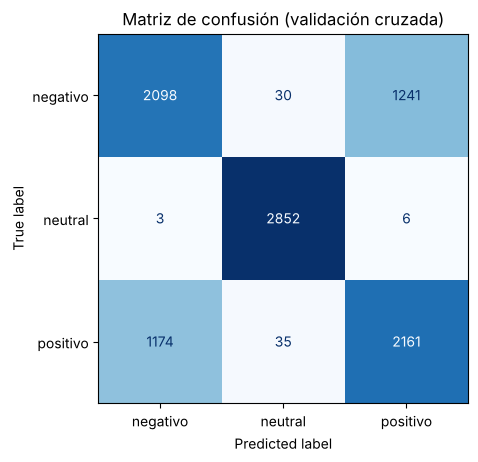

In [4]:
def validar(modelo):
    """Validación cruzada de 5 pliegues sobre entrenamiento: accuracy por pliegue y predicción fuera de pliegue de cada reseña."""
    res = cross_validate(modelo, X_ent, y_ent, cv=CV, n_jobs=-1, return_estimator=True, return_indices=True)
    pred = pd.Series(index=X_ent.index, dtype=object)
    for estimador, idx in zip(res["estimator"], res["indices"]["test"]):
        pred.iloc[idx] = estimador.predict(X_ent.iloc[idx])
    acc = res["test_score"]
    print(f"Accuracy en validación cruzada: {acc.mean():.4f} ± {acc.std():.4f}   (pliegues: {np.round(acc, 4)})")
    print(f"F1 macro: {f1_score(y_ent, pred, average='macro'):.4f}\n")
    print(classification_report(y_ent, pred, labels=LABELS, digits=3))
    ConfusionMatrixDisplay.from_predictions(y_ent, pred, labels=LABELS, cmap="Blues", colorbar=False)
    plt.title("Matriz de confusión (validación cruzada)"); plt.show()
    return acc.mean()


acc_cv = validar(modelo)

**Resultado.** Mejores hiperparámetros: `C = 10`, `min_df = 2`, unigramas. Accuracy **0,7407 ± 0,0086**: **+1,5 puntos** sobre la iteración 02 y la mejor hasta ahora.
- Regularizar menos (`C = 10`) y descartar las palabras que aparecen en una sola reseña (`min_df = 2`) es lo que más ayuda.
- Los bigramas **no** fueron elegidos: agregan miles de columnas sin mejorar.

**Siguiente paso:** combinar varios modelos lineales.

## 5. Envío a Kaggle y modelo guardado
Se reentrena con **todo** `train.csv`, se predice `eval.csv`, se valida el formato (`id,answer`, 3.000 ids, etiquetas válidas) y se guardan el envío y el modelo. Al final se recarga el `.joblib` y se comprueba que reproduce el envío.

In [5]:
NOMBRE = "iter04_logistica_ajustada"

modelo_final = clone(modelo).fit(train["text"], train["label"])  # todo train.csv (12.000 reseñas)
envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})

assert list(envio.columns) == ["id", "answer"]
assert len(envio) == 3000 and envio["id"].is_unique and set(envio["id"]) == set(muestra["id"])
assert envio["answer"].isin(LABELS).all()

ruta_envio = ENVIOS_DIR / f"{NOMBRE}.csv"
ruta_modelo = MODELOS_DIR / f"{NOMBRE}.joblib"
envio.to_csv(ruta_envio, index=False)
joblib.dump(modelo_final, ruta_modelo, compress=3)

# Replicabilidad: el modelo guardado reproduce exactamente el envío
recargado = joblib.load(ruta_modelo)
assert (recargado.predict(eval_df["text"]) == pd.read_csv(ruta_envio)["answer"].values).all()
print(f"Envío: {ruta_envio.relative_to(RAIZ)} | modelo: {ruta_modelo.relative_to(RAIZ)} "
      f"({ruta_modelo.stat().st_size / 1e6:.1f} MB)")
print("Predicciones por clase:", envio["answer"].value_counts().to_dict())
print("El modelo recargado reproduce el envío: OK")

Envío: kaggle_iteraciones/iter04_logistica_ajustada.csv | modelo: models/iteraciones/iter04_logistica_ajustada.joblib (0.1 MB)
Predicciones por clase: {'positivo': 1093, 'negativo': 1072, 'neutral': 835}
El modelo recargado reproduce el envío: OK


## Historial de iteraciones
Accuracy en validación cruzada (5 pliegues sobre el 80 % de entrenamiento). Línea base trivial: 0,351.

| # | Iteración | Accuracy CV | Cambio (puntos) |
|---|---|---|---|
| 01 | Bolsa de palabras + Naive Bayes | 0,7047 | — |
| 02 | TF-IDF + regresión logística | 0,7252 | +2,0 |
| 03 | TF-IDF + Random Forest | 0,6760 | −4,9 |
| 04 | Regresión logística ajustada (GridSearchCV) | 0,7407 | +6,5 |